In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from transformers import SwinForImageClassification,SwinConfig
from torch.optim import AdamW
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import os
import ssl
from PIL import Image

c:\Users\Administrator\Desktop\swin\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## train

In [ ]:
ssl._create_default_https_context = ssl._create_unverified_context

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dir = "images"
train_dir = os.path.join(data_dir, "train_images")
valid_dir = os.path.join(data_dir, "val_images")
test_dir = os.path.join(data_dir, "test_images")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # Augmentation
    transforms.RandomRotation(15),     # Augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

# dataloaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# load model
model = SwinForImageClassification.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
num_classes = len(train_dataset.classes)
model.config.num_labels = num_classes
model.classifier = nn.Linear(model.config.hidden_size, num_classes)  # Thay lớp classifier cuối
model = model.to(device)

# optimizer và scheduler
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)  # LR nhỏ để tránh phá vỡ pretrained weights
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

# train
def train_fine_tune(model, train_loader, valid_loader, optimizer, scheduler, epochs=10):
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        # Training phase
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images).logits
            loss = nn.CrossEntropyLoss()(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
        
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation phase
        val_loss, val_acc = evaluate(model, valid_loader)
        val_losses.append(val_loss)
        
        # Lưu mô hình tốt nhất
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "models/swin_finetuned.pth")
        
        # Cập nhật LR
        scheduler.step()
        
        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.2f}%")
    
    return train_losses, val_losses

# Evaluate
def evaluate(model, data_loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            loss = nn.CrossEntropyLoss()(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = running_loss / len(data_loader.dataset)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [ ]:
train_losses, val_losses = train_fine_tune(model, train_loader, valid_loader, optimizer, scheduler, epochs=5)

Evaluating: 100%|██████████| 16/16 [00:20<00:00,  1.26s/it]


Epoch 1: Train Loss = 0.4238, Val Loss = 0.2396, Val Acc = 91.41%


Evaluating: 100%|██████████| 16/16 [00:19<00:00,  1.23s/it]


Epoch 2: Train Loss = 0.1811, Val Loss = 0.1742, Val Acc = 93.01%


Evaluating: 100%|██████████| 16/16 [00:17<00:00,  1.12s/it]


Epoch 3: Train Loss = 0.1521, Val Loss = 0.1600, Val Acc = 94.11%


Evaluating: 100%|██████████| 16/16 [00:12<00:00,  1.25it/s]


Epoch 4: Train Loss = 0.1380, Val Loss = 0.1445, Val Acc = 94.51%


Evaluating: 100%|██████████| 16/16 [00:16<00:00,  1.03s/it]


Epoch 5: Train Loss = 0.1240, Val Loss = 0.1309, Val Acc = 95.10%


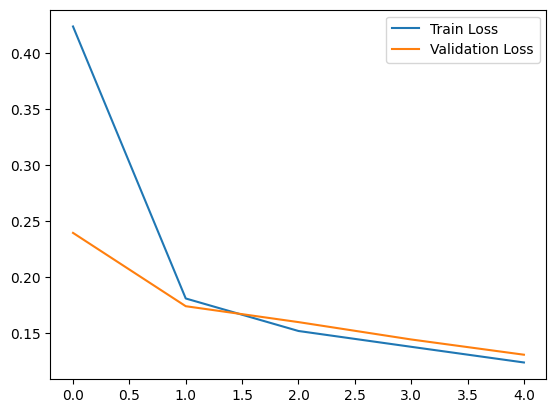

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
# plt.title("Fine-tuning Loss Curve")
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       250
           1       0.96      0.95      0.96       250
           2       0.95      0.93      0.94       250
           3       0.96      0.96      0.96       250

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



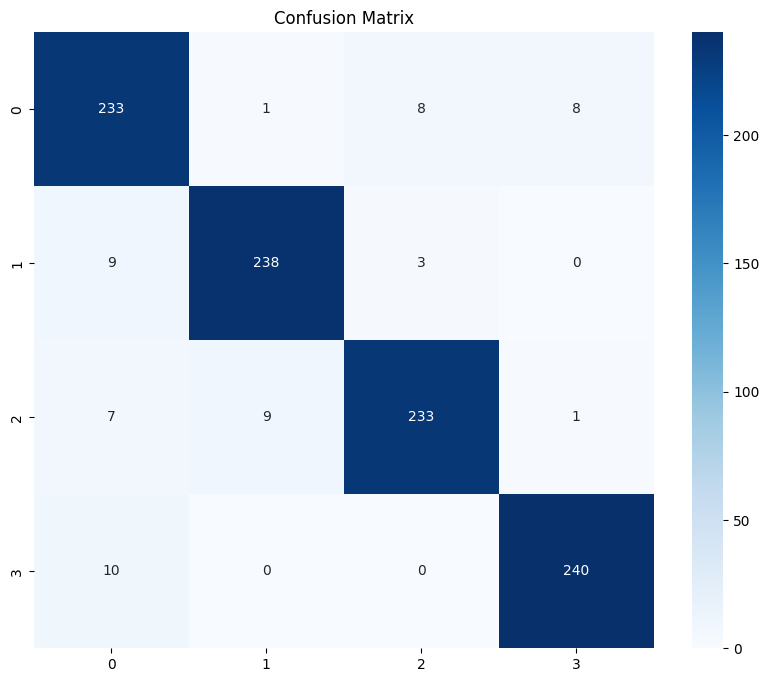

In [ ]:
# Confusion Matrix and Classification Report
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Evaluate

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dir = "images"
test_dir = os.path.join(data_dir, "test_images")
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

batch_size = 64
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

config = SwinConfig.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
config.num_labels = 4  # Sửa lại thành đúng số class của mô hình đã fine-tuned

model = SwinForImageClassification(config)
model.load_state_dict(torch.load('models/swin_finetuned.pth'))

model = model.to(device)
model.eval()
def evaluate(model, data_loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            loss = nn.CrossEntropyLoss()(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = running_loss / len(data_loader.dataset)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [ ]:
test_loss, test_acc = evaluate(model, test_loader)
print(f"\nTest Accuracy: {test_acc:.2f}%")

Evaluating: 100%|██████████| 16/16 [00:15<00:00,  1.00it/s]


Test Accuracy: 94.40%


In [ ]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       250
           1       0.96      0.95      0.96       250
           2       0.95      0.93      0.94       250
           3       0.96      0.96      0.96       250

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



<Figure size 800x600 with 0 Axes>

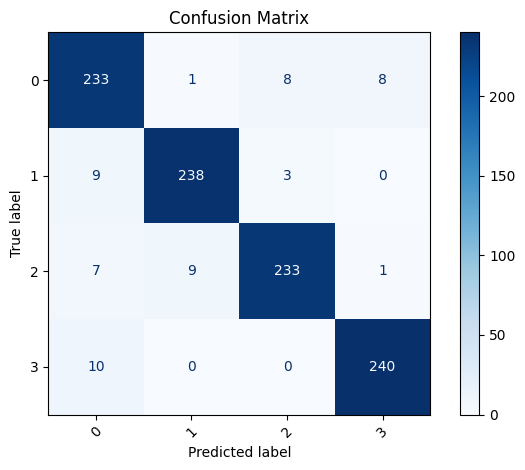

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

In [ ]:
label_map = {'BENIGN': 0, 'Group1' : 1, 'Group2': 2, "Syn": 3 }
labels_list = ['BENIGN', 'Group1' , 'Group2', "Syn"]

def predict_per_image(image_path):
    image = Image.open(image_path).convert('RGB')
    input_tensor = val_test_transform(image).unsqueeze(0)  # Thêm batch dimension
    input_tensor = input_tensor.to(device) 

    with torch.no_grad():
        output = model(input_tensor)

    _, predicted_class = torch.max(output.logits, 1)
    # print(f"Predicted class index: {predicted_class.item()}")
    return labels_list[predicted_class.item()]


def predict_many_images(label, folder_path):
    all_file_paths = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            full_path = os.path.join(root, file)
            all_file_paths.append(full_path)

    name_details_dict = {}

    for j in all_file_paths:
        r = predict_per_image(f"{j}")
        if r in name_details_dict:
            name_details_dict[r] += 1
        else:
            name_details_dict[r] = 1

    print(f'Label: {label}', name_details_dict)

In [ ]:
predict_many_images('BENIGN', 'test/images/benign')
predict_many_images('Syn', 'test/images/syn')
predict_many_images('UDP', 'test/images/udp')